Лабораторна робота №1

Виконав: Верещака Олександр ПР-2-2

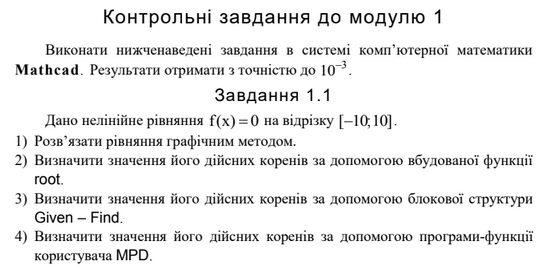

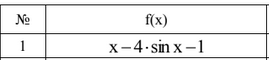

Аналітична похідна (SymPy): 1 - 4*cos(x)
Корені через root:
	->| -2.210083944092661
	->| -0.3421850529244582
	->| 2.7020613733260403
Корені через fsolve(Аналог Given - Find):
	->| -2.210083944092661
	->| -0.3421850529244582
	->| 2.7020613733260403
Корені через mpd:
	->| -2.2099609375
	->| -0.3427734375
	->| 2.7021484375


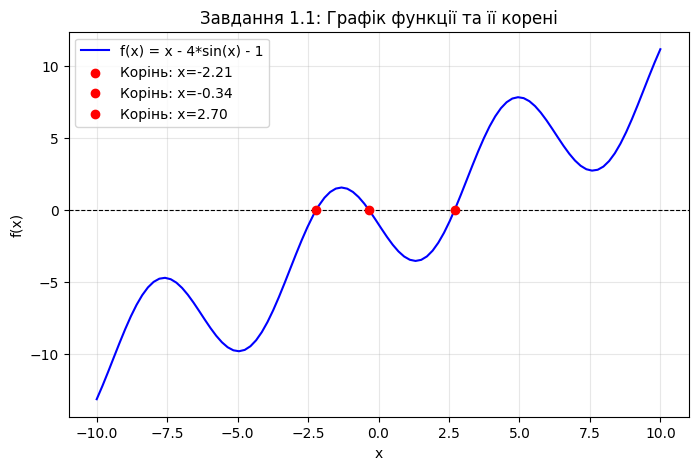

In [16]:
# Task 1.1
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.optimize import root, fsolve

x_sym = sp.Symbol("x")
f_sym = x_sym - 4 * sp.sin(x_sym) - 1
df_sym = sp.diff(f_sym, x_sym)
print(f"Аналітична похідна (SymPy): {df_sym}")

x = np.linspace(-10, 10, 100)
f_np = sp.lambdify(x_sym, f_sym, "numpy")
y = f_np(x)

list = [[-3, -2], [-1, 0], [2, 3]]
list_res = [root(f_np, (a + b) / 2).x[0] for a, b in list]
print("Корені через root:", *list_res, sep="\n\t->| ")

list_res_fsolve = [fsolve(f_np, (a + b) / 2)[0] for a, b in list]
print("Корені через fsolve(Аналог Given - Find):", *list_res_fsolve, sep="\n\t->| ")


def mpd(f, a, b, eps=0.001):
    while (b - a) / 2 > eps:
        c = (a + b) / 2
        if f(c) == 0:
            return c
        elif f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return (a + b) / 2


list_res_mpd = [mpd(f_np, a, b) for a, b in list]
print("Корені через mpd:", *list_res_mpd, sep="\n\t->| ")


# Будуємо графік функції та відмічаємо корені
plt.figure(figsize=(8, 5))
plt.plot(x, y, label="f(x) = x - 4*sin(x) - 1", color="blue")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Відмітка коренів на графіку
for root_x in list_res:
    plt.scatter(root_x, [0], color="red", zorder=5, label=f"Корінь: x={root_x:.2f}")

plt.title("Завдання 1.1: Графік функції та її корені")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

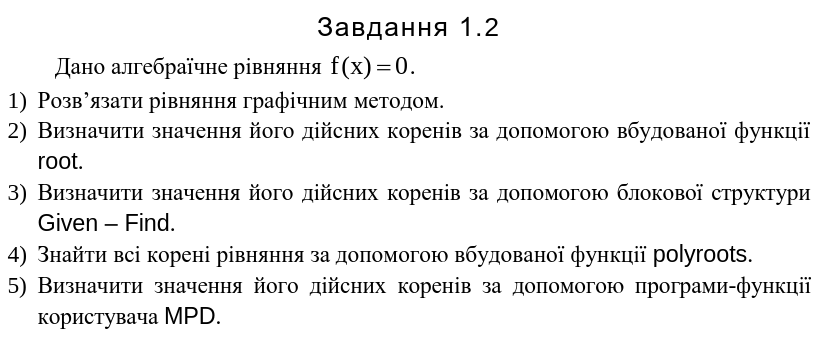

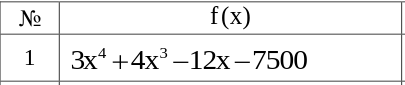

Аналітична похідна (SymPy): 12*x**3 + 12*x**2 - 12
Корені через root:
	->| -7.408549380194432
	->| 6.778928536224715
Корені через roots_poly:
	->| (-7.408549380194579+0j)
	->| (-0.3518562446817408+7.046641181232678j)
	->| (-0.3518562446817408-7.046641181232678j)
	->| (6.778928536224718+0j)
Корені через fsolve(Аналог Given - Find):
	->| -7.408549380194432
	->| 6.778928536224715
Корені через mpd:
	->| -7.4091796875
	->| 6.779052734375


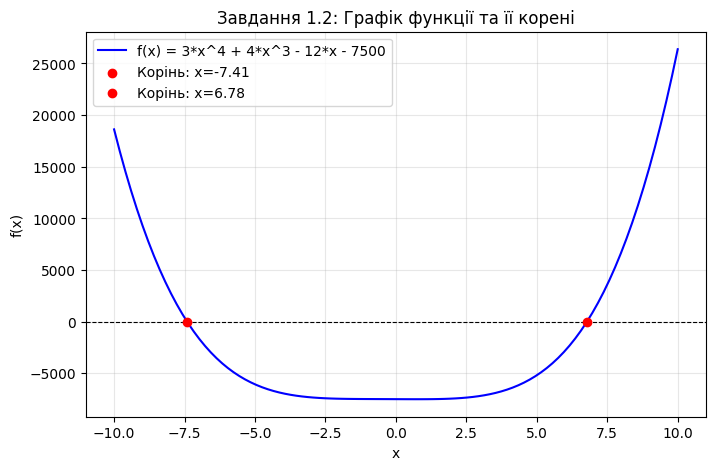

In [15]:
# Task 1.2
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.optimize import root, fsolve

x_sym = sp.Symbol("x")
f_sym = 3 * x_sym**4 + 4 * x_sym**3 - 12 * x_sym - 7500
df_sym = sp.diff(f_sym, x_sym)
print(f"Аналітична похідна (SymPy): {df_sym}")

x = np.linspace(-10, 10, 100)
f_np = sp.lambdify(x_sym, f_sym, "numpy")
y = f_np(x)

list = [[-8, -6], [5, 8]]
list_res = [root(f_np, (a + b) / 2).x[0] for a, b in list]
print("Корені через root:", *list_res, sep="\n\t->| ")

roots_poly = np.roots([3, 4, 0, -12, -7500])
print("Корені через roots_poly:", *roots_poly, sep="\n\t->| ")

list_res_fsolve = [fsolve(f_np, (a + b) / 2)[0] for a, b in list]
print("Корені через fsolve(Аналог Given - Find):", *list_res_fsolve, sep="\n\t->| ")


def mpd(f, a, b, eps=0.001):
    while (b - a) / 2 > eps:
        c = (a + b) / 2
        if f(c) == 0:
            return c
        elif f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return (a + b) / 2


list_res_mpd = [mpd(f_np, a, b) for a, b in list]
print("Корені через mpd:", *list_res_mpd, sep="\n\t->| ")

# Будуємо графік функції та відмічаємо корені
plt.figure(figsize=(8, 5))
plt.plot(x, y, label="f(x) = 3*x^4 + 4*x^3 - 12*x - 7500", color="blue")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Відмітка коренів на графіку
for root_x in list_res:
    plt.scatter(root_x, [0], color="red", zorder=5, label=f"Корінь: x={root_x:.2f}")

plt.title("Завдання 1.2: Графік функції та її корені")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

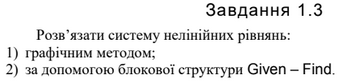

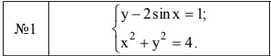

Корені через fsolve(Аналог Given - Find):
	->| [-1.75018878 -0.96790456]
	->| [0.4889068  1.93932208]


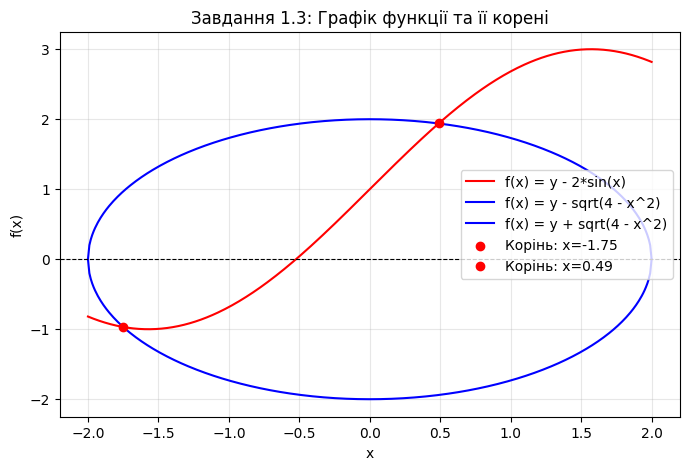

In [14]:
# Task 1.3
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.optimize import root, fsolve

x_sym = sp.Symbol("x")
y1 = 2 * sp.sin(x_sym) + 1
y2 = sp.sqrt(4 - x_sym**2)
y3 = -sp.sqrt(4 - x_sym**2)


def system(vars):
    x = vars[0]  # беремо x зі списку невідомих
    y = vars[1]  # беремо y зі списку невідомих

    # Записуємо рівняння (те, що дорівнює нулю)
    eq1 = y - 2 * np.sin(x) - 1
    eq2 = x**2 + y**2 - 4

    return [eq1, eq2]


x = np.linspace(-2, 2, 400)
f_np1 = sp.lambdify(x_sym, y1, "numpy")
f_np2 = sp.lambdify(x_sym, y2, "numpy")
f_np3 = sp.lambdify(x_sym, y3, "numpy")
y1 = f_np1(x)
y2 = f_np2(x)
y3 = f_np3(x)

list = [[-1.7, -1], [0.5, 2]]

list_res_fsolve = [fsolve(system, [a, b]) for a, b in list]
print("Корені через fsolve(Аналог Given - Find):", *list_res_fsolve, sep="\n\t->| ")


# Будуємо графік функції та відмічаємо корені
plt.figure(figsize=(8, 5))
plt.plot(x, y1, label="f(x) = y - 2*sin(x)", color="red")
plt.plot(x, y2, label="f(x) = y - sqrt(4 - x^2)", color="blue")
plt.plot(x, y3, label="f(x) = y + sqrt(4 - x^2)", color="blue")

plt.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Відмітка коренів на графіку
for root_x, root_y in list_res_fsolve:
    plt.scatter(root_x, root_y, color="red", zorder=5, label=f"Корінь: x={root_x:.2f}")

plt.title("Завдання 1.3: Графік функції та її корені")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

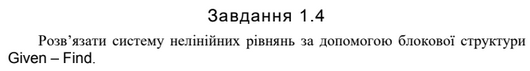

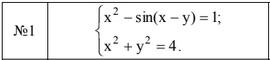

In [13]:
# Task 1.4
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.optimize import root, fsolve


def system(vars):
    x = vars[0]
    y = vars[1]

    eq1 = x**2 - np.sin(x - y) - 1
    eq2 = x**2 + y**2 - 4

    return [eq1, eq2]


list = [[1, 1], [-1, 1]]

list_res_fsolve = [fsolve(system, [a, b]) for a, b in list]
print("Корені через fsolve(Аналог Given - Find):", *list_res_fsolve, sep="\n\t->| ")

Корені через fsolve(Аналог Given - Find):
	->| [0.17436698 1.99238454]
	->| [-0.66637727  1.88572038]
